In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Gráficos de densidad y estimación de distribución

Los gráficos de densidad representan la **distribución de probabilidad** de la variable que estamos analizando.

Es una **estimación** de lo que sería la distribución teórica de los datos.

Y esta **estimación de distribución** se obtiene usando técnicas que en inglés se conocen como *kernel density estimation* (se basa en el uso de distribuciones Gaussianas).

### Distribuciones de probabilidad (gráficos de densidad de probabilidad)

Una distribución de probabilidad es una manera de representar gráficamente la probabilidad de ocurrencia de los diferentes valores en la variable que estamos analizando.

Lo más relevante de una distribución de probabilidad son:

- Las diferentes probabilidades de ocurrencia están entre 0 (probabilidad nula) y 1 (probabilidad máxima)
- El área bajo la curva de esta distribución debe ser exactamente igual a 1

El hecho de que los histogramas sean gráficos de barras en ocasiones dificulta interpretar fácilmente la distribución de nuestros datos, así que a veces es preferible graficar la distribución de probabilidad.

In [2]:
df = pd.read_csv('./data.csv')
df

,var_1,var_2,var_3
0,0.496714,0.645917,0.125977
1,-0.138264,0.570778,0.204921
2,0.647689,0.356097,0.164068
3,1.523030,0.986515,0.127733
4,-0.234153,0.605775,0.115127
...,...,...,...
495,0.538910,0.680141,0.113182
496,-1.037246,0.618611,0.267363
497,-0.190339,0.752717,0.269974
498,-0.875618,0.158605,0.251157


Text(0, 0.5, 'Frecuencia')

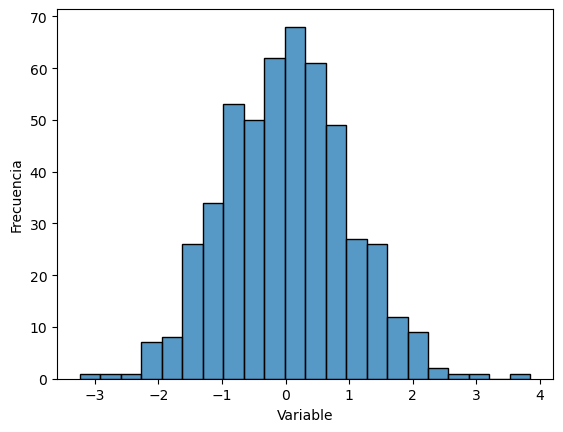

In [3]:
ax = sns.histplot(data=df['var_1'])
ax.set_xlabel('Variable')
ax.set_ylabel('Frecuencia')

Para el gráfico de densidad de probabilidad (o de distribución de probabilidad) es cambiando la escala del eje vertical, para que en lugar de frecuencia nos muestra probabilidades asociadas a cada intervalo

Text(0, 0.5, 'Densidades de probabilidad')

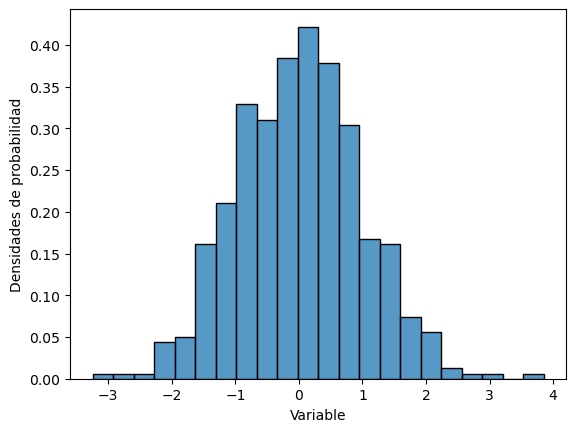

In [10]:
ax = sns.histplot(data=df['var_1'], stat='density')
ax.set_xlabel('Variable')
ax.set_ylabel('Densidades de probabilidad')

La altura de cada barra es ahora una **densidad de probabilidad**, la probabilidad de ocurrencia por ancho del intervalo para cada intervalo.

Todas estas densidades ahora están entre 0 y 1 y si calculamos el área bajo la curva el resultado debería ser exactamente igual a 1.

Lo que resta ahora es estimar la distribución teórica de los datos, para lo cual podemos usar el argumento `kde = True`en `histplot()`:

Text(0, 0.5, 'Densidades de probabilidad')

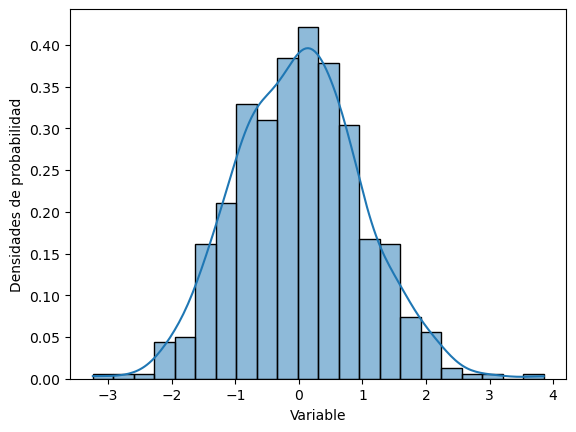

In [11]:
ax = sns.histplot(data=df['var_1'], stat='density', kde=True)
ax.set_xlabel('Variable')
ax.set_ylabel('Densidades de probabilidad')

La línea continua de color azul claro es la densidad de probabilidad de nuestra variable.

La densidad de probabilidad **es independiente del número de bins usados para dibujar el histograma** (pues se calcula directamente a partir de los datos, sin considerar intervalos).

Text(0, 0.5, 'Densidades de probabilidad')

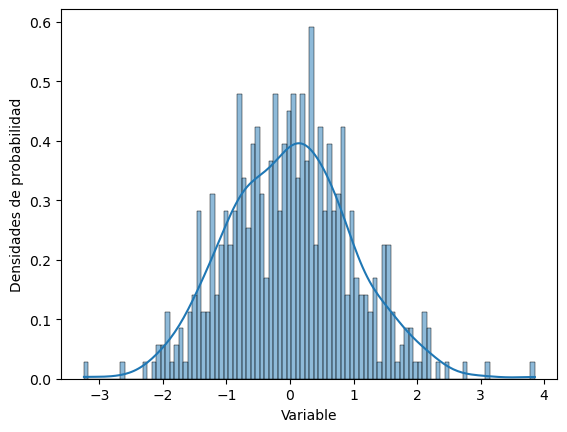

In [6]:
ax = sns.histplot(data=df['var_1'], stat='density', kde=True, bins=100)
ax.set_xlabel('Variable')
ax.set_ylabel('Densidades de probabilidad')

Text(0, 0.5, 'Densidades de probabilidad')

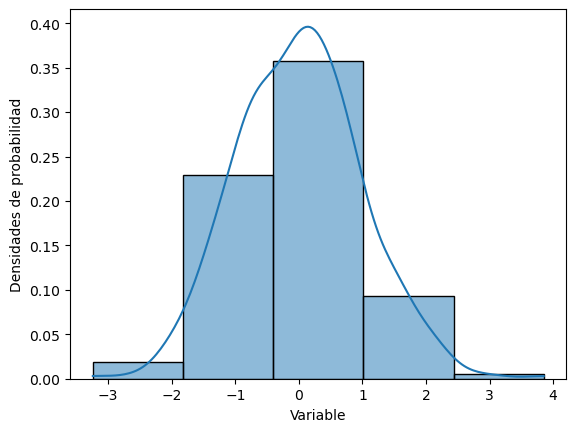

In [7]:
ax = sns.histplot(data=df['var_1'], stat='density', kde=True, bins=5)
ax.set_xlabel('Variable')
ax.set_ylabel('Densidades de probabilidad')

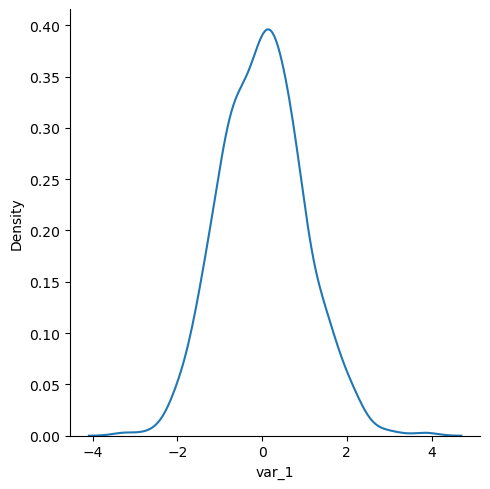

In [12]:
#Distribución de probabilidades directamente
ax = sns.displot(df['var_1'], kind='kde')

Podemos ver la posibilidad de los valores extremos, la mediana y el IQR y superponerlo a la gráfica de distribución de probabilidades usando gráficos de violín (violinplot):

Text(0, 0.5, 'Valores')

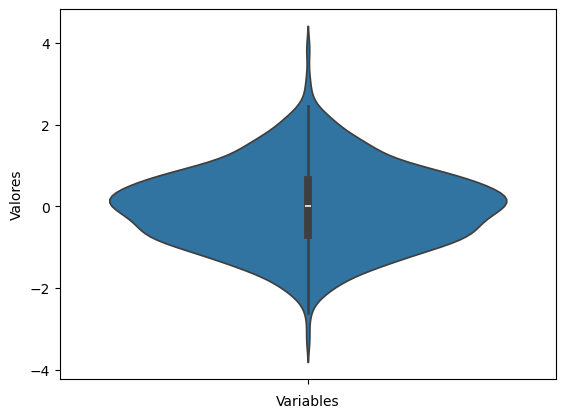

In [13]:
ax = sns.violinplot(data=df['var_1'])
ax.set_xlabel('Variables')
ax.set_ylabel('Valores')

Tenemos que:

- La pequeña caja de color negro corresponde al rango intercuartiles
- La mediana es el pequeño punto blanco dentro de esa caja
- Las líneas por encima y por debajo de la caja son los bigotes
- Las curvas de color azul (a la izquierda y derecha) son la densidad de probabilidades estimada
- La escala vertical no indica densidades de probabilidad sino valores de la variable (asociados al *boxplot*)

### Ejemplo práctico

En probabilidad, la puntuación o valor Z es una medida estadística que indica la distancia de un punto de datos en relación con la media de un grupo, expresada en unidades de la desviación estándar.

- Un valor Z positivo significa que la observación está por encima de la media
- Uno negativo indica que está por debajo
- Un Z de cero significa que está exactamente en la media

Esta puntuación permite estandarizar datos para compararlos y analizar su posición dentro de una distribución normal estándar, que tiene una media de 0 y una desviación estándar de 1.

#### ¿Para qué se utiliza la puntuación Z?

- Estandarización de datos: Convierte los datos de cualquier distribución normal a una distribución normal estándar, donde los valores pueden ser fácilmente comparados y analizados.
- Mediación de posición relativa: Indica cuán alejado está un valor particular de la media de la muestra o población.
- Realización de pruebas estadísticas: Es fundamental en las pruebas de hipótesis y en la interpretación de los resultados de pruebas Z, que comparan una estadística observada con un parámetro hipotético en unidades de desviación estándar.
- Determinación de probabilidades: Se usa junto a la tabla normal estándar o tabla Z para calcular la probabilidad de que ocurra un evento, ya sea por encima, por debajo o entre dos valores.

#### ¿Cómo se calcula la puntuación Z?

La fórmula de la puntuación Z es: 

$$Z=\frac{X-\mu}{\sigma}$$

Donde:

- $X$ es la puntuación o valor individual de los datos que se quieren estandarizar
- $\mu$ (mu) es la media de la población
- $\sigma$ (sigma) es la desviación estándar de la población

##### Ejemplo

Supongamos que la altura $X$ (en cm) de una población sigue una distribución normal: $S \sim N$ ($\mu = 170, \sigma = 10$)

¿Cuál es la probabilidad de que una persona mida más de 180 cm?

- **Paso 1**: Calcular el puntaje Z:

$Z=\frac{180-170}{10}=1$

- **Paso 2**: Usar la función de distribución normal estándar

$\phi(1) \approx 0.841344746$

La probabilidad buscada es:

$P(X>180)=1-\phi(1)=1-0.841344746 \approx 0.1587 \rightarrow 15.87%$

¿Cuál es la probabilidad de que mida entre 160 y 180 cm?

Calcular Z para los extremos:

Para $X=160$

$Z=\frac{160-170}{10}=-1$

$\phi(-1) \approx 0.158655254$

Para $X=180$

$Z=\frac{180-170}{10}=1$

$\phi(1) \approx 0.841344746$

Entonces:

$P(160 \leq X \leq 180)=\phi(1)-\phi(-1)=0.841344746-0.158655254=0.682689492 \approx 0.6827 \rightarrow 68.27%$ (coincide con la regla empírica: $\approx 68%$ dentro de $\pm 1 \sigma$)

#### Tarea

Hacer esto para los datos de 15 a 18, obtener el porcentaje que hay en el rango de 16 a 17 años. Hacer 5 preguntas variables numericas o categoricas para meterlo en un cuestionario para contestar ¿qué materias son las mas dificiles? de que semestre son? si les gusta la carrera? ¿A que piensan dedicarse?, con eso hacer una aplicación para obtener datos reales de esto, más o menos unos 50 a 70 alumnos. La idea es hacer una lluvia de ideas de esto para obtener las mejores preguntas para hacer un cuestionario de esto. Despues de esto usar ETL, agarramos los datos en csv, transformarlos, datos no obligatorios todos, bajar los datos, la guardamos en una bd, hacemos el workstation.